### Applying the MINE estimator in the context of an AWGN channel for a BPSK and QPSK modulations and for a Gaussian signal


--- Starting with: BPSK ---
[BPSK] SNR: -10dB | MINE: 0.126 | Theory: 0.069
[BPSK] SNR: -6dB | MINE: 0.349 | Theory: 0.162
[BPSK] SNR: -2dB | MINE: 0.602 | Theory: 0.353
[BPSK] SNR:  2dB | MINE: 0.942 | Theory: 0.685
[BPSK] SNR:  6dB | MINE: 1.022 | Theory: 1.158
[BPSK] SNR: 10dB | MINE: 1.023 | Theory: 1.730
[BPSK] SNR: 14dB | MINE: 0.943 | Theory: 2.354
[BPSK] SNR: 18dB | MINE: 1.109 | Theory: 3.001

--- Starting with: QPSK ---
[QPSK] SNR: -10dB | MINE: 0.230 | Theory: 0.138
[QPSK] SNR: -6dB | MINE: 0.243 | Theory: 0.323
[QPSK] SNR: -2dB | MINE: 0.677 | Theory: 0.706
[QPSK] SNR:  2dB | MINE: 1.252 | Theory: 1.370
[QPSK] SNR:  6dB | MINE: 1.922 | Theory: 2.316
[QPSK] SNR: 10dB | MINE: 1.992 | Theory: 3.459
[QPSK] SNR: 14dB | MINE: 2.081 | Theory: 4.707
[QPSK] SNR: 18dB | MINE: 2.048 | Theory: 6.002

--- Starting with: GAUSSIAN ---
[GAUSSIAN] SNR: -10dB | MINE: 0.202 | Theory: 0.069
[GAUSSIAN] SNR: -6dB | MINE: 0.250 | Theory: 0.162
[GAUSSIAN] SNR: -2dB | MINE: 0.588 | Theory: 0.353
[

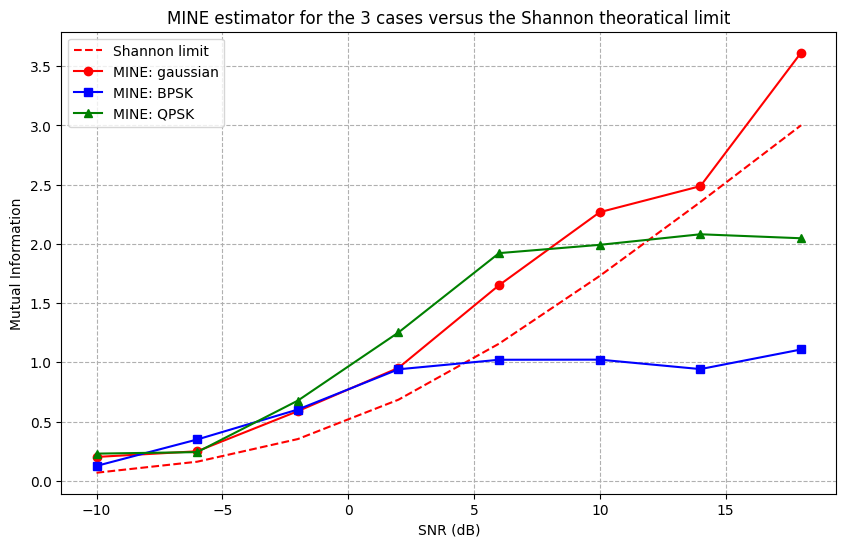

In [6]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt


##### The MINE Network Architecture (The statistics network) #######
class MineNet(nn.Module):
    def __init__(self, x_dim, y_dim):
        super(MineNet, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(x_dim + y_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x, y):
        return self.layers(torch.cat([x, y], dim=-1))

##### a SISO channel with BPSK/QPSK/Gaussian signals through an AWGN channel #####
class CommChannel:
    def __init__(self, n_samples):
        self.n = n_samples

    def generate_data(self, mode, snr_db):
        snr = 10**(snr_db / 10.0)

        if mode == 'bpsk':
            x = (1 - 2 * np.random.randint(0, 2, self.n)).astype(np.float32).reshape(-1, 1)
            N0 = 1 / snr
            noise = (np.sqrt(N0/2) * np.random.randn(self.n)).astype(np.float32).reshape(-1, 1)
            y = x + noise

        elif mode == 'qpsk':
            x_i = (1 - 2 * np.random.randint(0, 2, self.n))
            x_q = (1 - 2 * np.random.randint(0, 2, self.n))
            x = np.stack([x_i, x_q], axis=1).astype(np.float32) / np.sqrt(2)
            N0 = 1 / snr
            noise = (np.sqrt(N0/2) * np.random.randn(self.n, 2)).astype(np.float32) # Noise must also be (N, 2)
            y = x + noise

        elif mode == 'gaussian':
            x = np.random.randn(self.n, 1).astype(np.float32)
            N0 = 1 / snr
            noise = (np.sqrt(N0/2) * np.random.randn(self.n, 1)).astype(np.float32)
            y = x + noise

        return torch.from_numpy(x), torch.from_numpy(y)

#### we train the MINE estimator ########
def train_mine(x_data, y_data, x_dim, y_dim, epochs, batch_size):
    x_data = x_data.float()
    y_data = y_data.float()
    model = MineNet(x_dim, y_dim)
    opt = torch.optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(epochs):
        idx = torch.randperm(x_data.size(0))[:batch_size]
        x_sample = x_data[idx]
        y_sample = y_data[idx]

        t_joint = model(x_sample, y_sample)
        y_marginal = y_sample[torch.randperm(batch_size)]
        t_marginal = model(x_sample, y_marginal)

        # MINE estimator using the Donsker-Varadhan formulation
        mi = (torch.mean(t_joint) - torch.log(torch.mean(torch.exp(t_marginal)))) / np.log(2)
        loss = -mi

        opt.zero_grad()
        loss.backward()
        opt.step()

    return mi.item()

#### We compare the estimated MI using the MINE to the Shannon capacity
#### for the three cases ###

##### Parameters #####
epochs = 10000
batch_size=500
snr_range = np.arange(-10, 21, 4)
n_samples = 10000
modulations = ['bpsk', 'qpsk', 'gaussian']
results = {modulation: [] for modulation in modulations}
channel = CommChannel(n_samples)

for modulation in modulations:
    print(f"\n--- Starting with: {modulation.upper()} ---")

    # QPSK uses 2D (I and Q)
    dim = 2 if modulation == 'qpsk' else 1

    for snr in snr_range:
        x, y = channel.generate_data(modulation, snr)

        # We train the MINE estimator
        est_mi = train_mine(x, y, dim, dim, epochs, batch_size)

        results[modulation].append(est_mi)

        # Theoretical Capacity
        theo_factor = 1.0 if modulation == 'qpsk' else 0.5
        c_theo = theo_factor * np.log2(1 + 10**(snr/10.0))

        print(f"[{modulation.upper()}] SNR: {snr:2}dB | MINE: {est_mi:.3f} | Theory: {c_theo:.3f}")

#### Plot figures ######
plt.figure(figsize=(10, 6))
snr_lin = 10**(snr_range/10)
plt.plot(snr_range, 0.5 * np.log2(1 + snr_lin), 'r--', label='Shannon limit')
plt.plot(snr_range, results['gaussian'], 'ro-', label='MINE: gaussian')
plt.plot(snr_range, results['bpsk'], 'bs-', label='MINE: BPSK')
plt.plot(snr_range, results['qpsk'], 'g^-', label='MINE: QPSK')

plt.title("MINE estimator for the 3 cases versus the Shannon theoratical limit")
plt.xlabel("SNR (dB)")
plt.ylabel("Mutual Information")
plt.grid(True, which='both', linestyle='--')
plt.legend()
plt.show()